# Assignment 1 – Spam Email Classification


## Problem Statement



Convert email text into TF-IDF features and train a Naive Bayes classifier to classify spam vs non-spam emails. Evaluate precision, recall and F1-score.





## Dataset Description

The **SMS Spam Collection Dataset** contains **5,574 SMS messages** in English. Each message is labeled as either **spam** or **ham (legitimate)**. This dataset is widely used for text classification and spam filtering research because it provides real-world examples of both normal and spam messages.

## Dataset Attributes

| Attribute | Description |
|-----------|-------------|
| **v1** | Message label (**ham** or **spam**) |
| **v2** | SMS message text |


In [2]:
#import the required libs

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix,ConfusionMatrixDisplay


In [5]:
df = pd.read_csv("spam.csv", encoding="latin-1")
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [6]:
# Remove unnecessary columns
df = df[["v1", "v2"]]

# Rename columns
df.columns = ["Label", "Message"]

# Display the first few rows
df.head()

,Label,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
print("Shape of Dataset:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Information:")
df.info()

Shape of Dataset: (5572, 2)

Columns:
Index(['Label', 'Message'], dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Label    5572 non-null   object
 1   Message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [12]:
# Statistical summary
df.describe()

,Label,Message
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [13]:
# Check missing values
df.isnull().sum()

,0
Label,0
Message,0


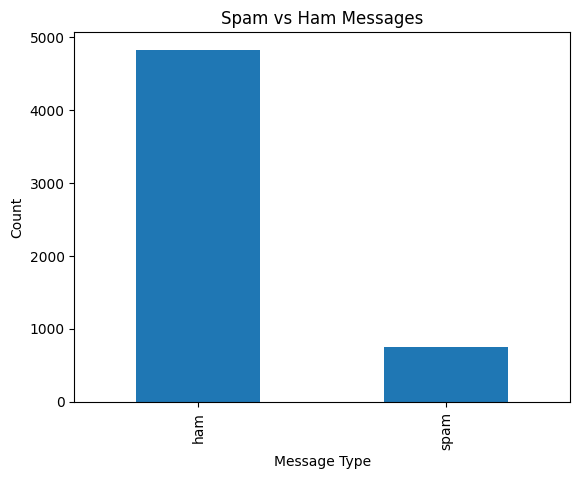

In [16]:
df["Label"].value_counts().plot(kind="bar")

plt.title("Spam vs Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Count")

plt.show()

In [17]:
print("Duplicate Messages:", df.duplicated().sum())

Duplicate Messages: 403


In [18]:
df.drop_duplicates(inplace=True)

print("Dataset Shape:", df.shape)

Dataset Shape: (5169, 2)


In [19]:
df["Label"] = df["Label"].map({
    "ham": 0,
    "spam": 1
})

df.head()

,Label,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [20]:
X = df["Message"]
y = df["Label"]

print("Number of Messages:", X.shape)
print("Number of Labels:", y.shape)

Number of Messages: (5169,)
Number of Labels: (5169,)


In [21]:
# Create TF-IDF Vectorizer
tfidf = TfidfVectorizer(stop_words="english")

# Transform the message text into numerical features
X_tfidf = tfidf.fit_transform(X)

print("Shape of TF-IDF Matrix:", X_tfidf.shape)

Shape of TF-IDF Matrix: (5169, 8404)


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples :", X_test.shape[0])

Training Samples: 4135
Testing Samples : 1034


In [25]:
# Create the model
nb_model = MultinomialNB()

# Train the model
nb_model.fit(X_train, y_train)

print("Naive Bayes model trained successfully.")

Naive Bayes model trained successfully.


In [26]:
y_pred = nb_model.predict(X_test)

In [27]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-Score :", round(f1, 4))

Accuracy : 0.9652
Precision: 1.0
Recall   : 0.7517
F1-Score : 0.8583


In [28]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       889
           1       1.00      0.75      0.86       145

    accuracy                           0.97      1034
   macro avg       0.98      0.88      0.92      1034
weighted avg       0.97      0.97      0.96      1034



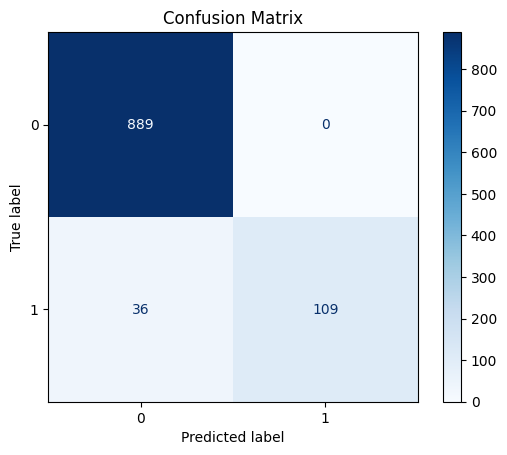

In [29]:
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(cm).plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

## Model Performance

The Naive Bayes classifier was trained using TF-IDF features extracted from the SMS messages.

The model achieved the following performance on the testing dataset:

- **Accuracy:** 96.52%
- **Precision:** 100.00%
- **Recall:** 75.17%
- **F1-Score:** 85.83%

The high accuracy and perfect precision indicate that the classifier is highly effective in identifying spam messages with very few false positives. Although the recall is comparatively lower, the overall F1-score demonstrates that the model performs well in spam classification.

## Observations

- The SMS Spam Collection dataset originally contained **5,572 messages**.
- After removing duplicate records, **5,169 unique messages** remained.
- The dataset contained **no missing values**.
- The text messages were converted into **8,404 TF-IDF features**.
- The dataset was divided into **4,135 training samples** and **1,034 testing samples**.
- The Multinomial Naive Bayes classifier achieved an **accuracy of 96.52%**.
- The model obtained a **precision of 100.00%**, indicating that messages predicted as spam were highly accurate.
- The **recall was 75.17%**, showing that most spam messages were successfully detected.
- The overall **F1-score of 85.83%** indicates a good balance between precision and recall.
- Overall, the model performed effectively for spam message classification.